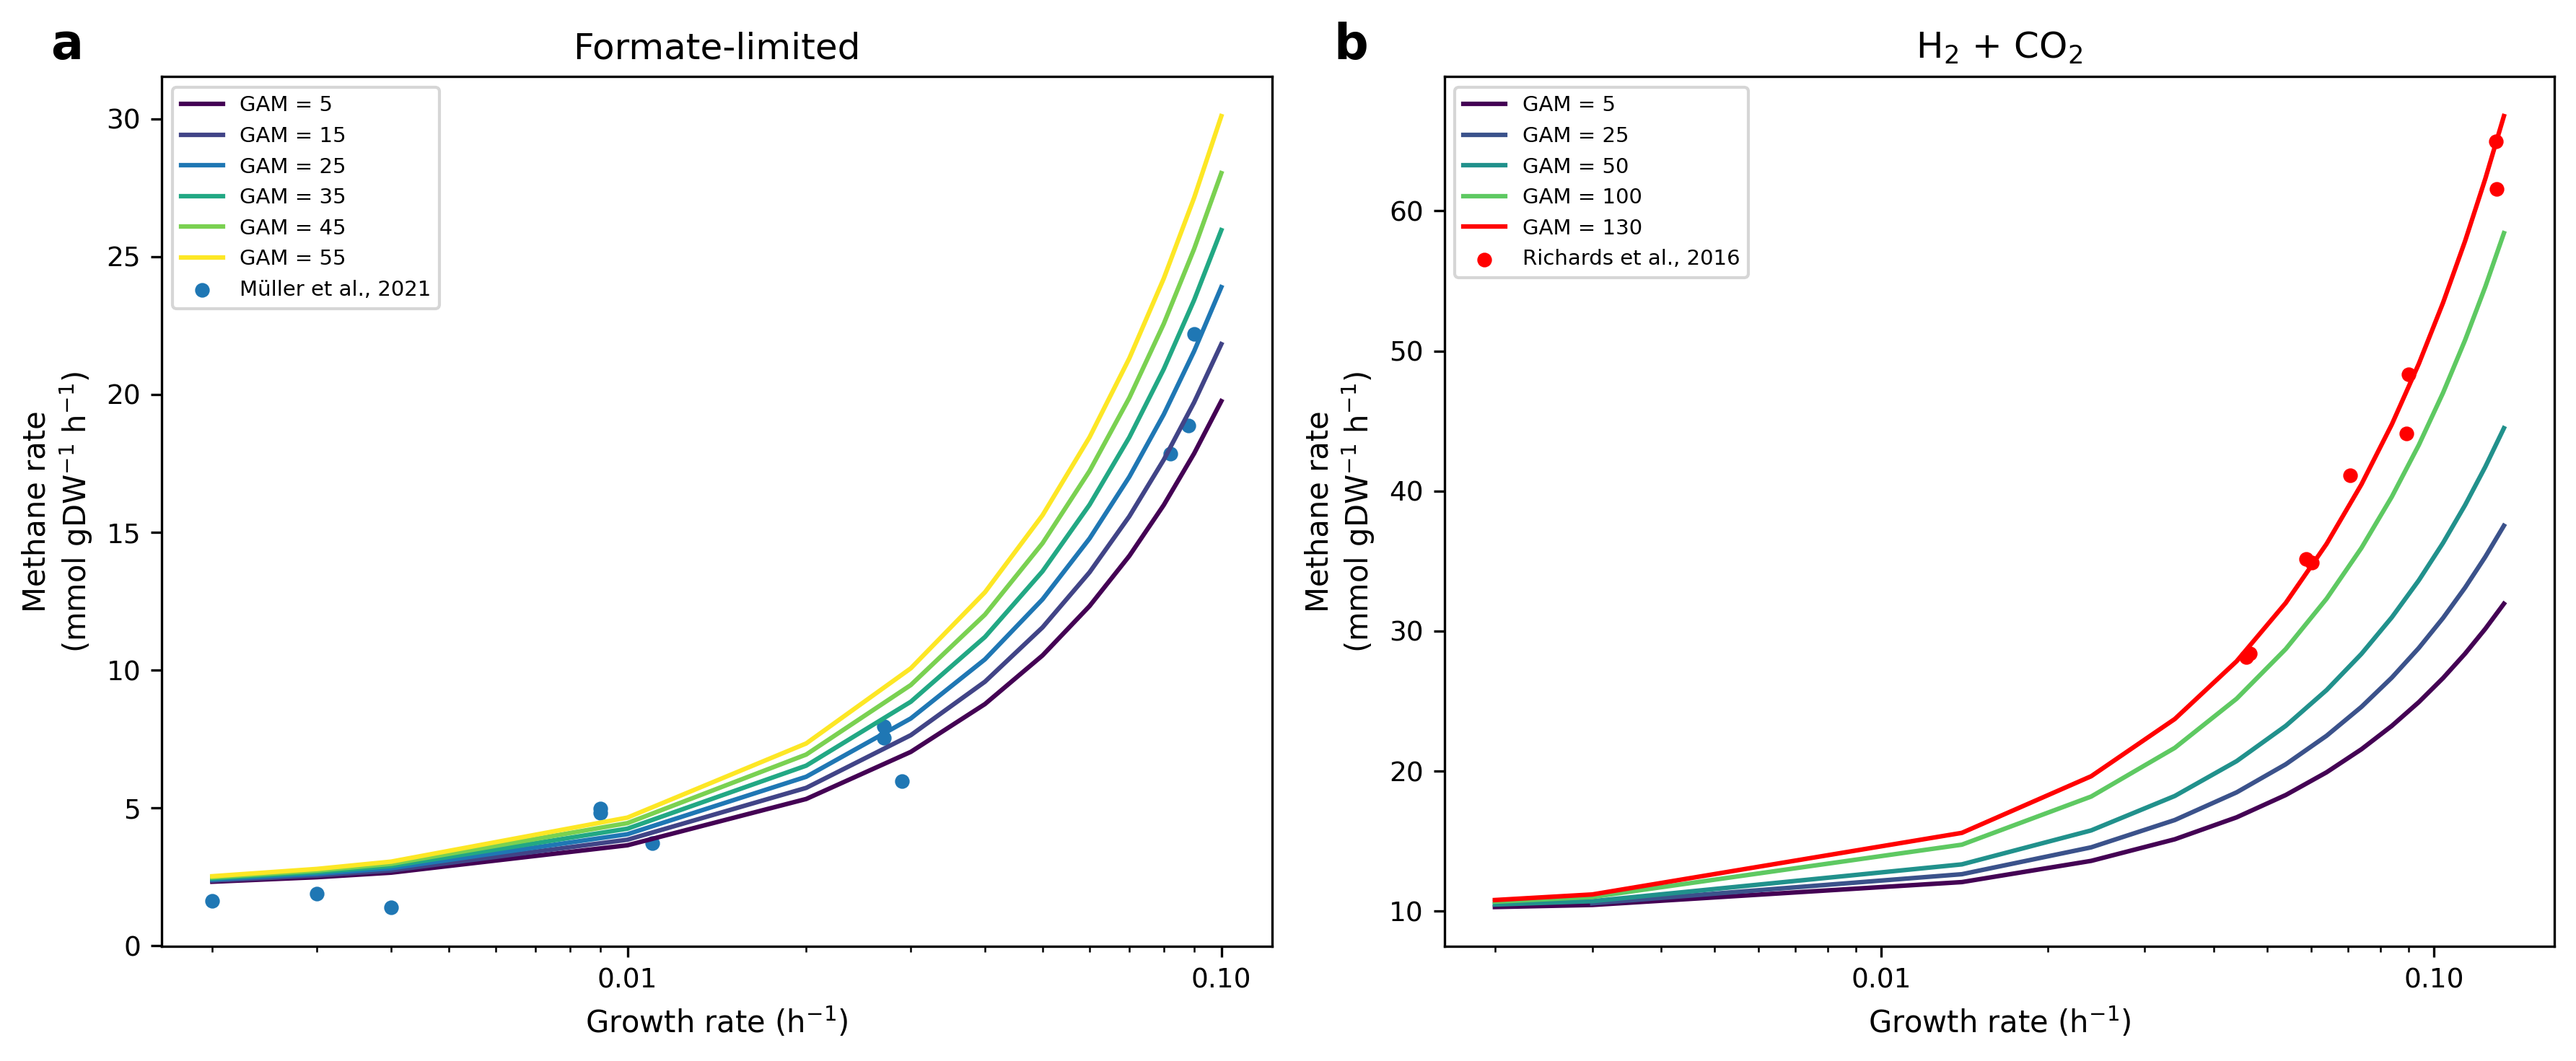

In [1]:
from simulation import Simulation
from extract_fluxes import Fluxes
import matplotlib.pyplot as plt
import  numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, FormatStrFormatter

def formate_limited_simulation(GAM):
    total_protein_mass=0.6
    up_formate_ratio=0.75*total_protein_mass
    methane_id,formate_id = "R944","R895"
    # closed import H2 ,CO2 , CO ,Aceteta
    closed_reactions = ["R946", "R913", "R1165", "R983"]
    sim = Simulation()
    # objective is formate 
   
    sim.set_parameter(model_file='pcMMP.xml', objective="R895", GAM=GAM, NGAM=1, excel_file='pcMMP.xlsx')
    sim.set_constraint = [f"UP >= {up_formate_ratio}"]
    sim.close_reactions(closed_reactions)
    results = {
        "mu_list": [], "methane_list": []
    }
    mus=[0.002,0.003,0.004, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09,0.1]
    for i, mu in enumerate(mus, start=1):
        sim.file_path = f"output/lp_file_limited_{i}.lp"
        sim.output_file = f"output/output_limited_{i}.lp"
        if sim.check_mu_optimal(mu):
            fluxes = Fluxes(sim.model, f'output/output_limited_{i}.lp')
            results["mu_list"].append(mu)
            results["methane_list"].append(fluxes.extract_reaction_flux(methane_id))
           
        else:
            print(f"mu={mu} is not optimal")

    return results
    
def co2_limited_simulation(GAM):
    methane_id = "R944"
    closed_reactions = ["R1165", "R895"]
    simulation = Simulation()
    simulation.set_parameter(model_file='pcMMP.xml',objective="R913",GAM=GAM,NGAM=5,excel_file='pcMMP.xlsx')
    simulation.close_reactions(closed_reactions)
    total_protein_mass=0.6
    up_co2_ratio=0.44*total_protein_mass
    simulation.set_constraint = [f"UP >= {up_co2_ratio}"]
    results = {"mu_list": [], "methane_list": []}
    mus = [0.002, 0.003, 0.014, 0.024, 0.034, 0.044, 0.054, 0.064, 0.074, 0.084, 0.094, 0.104, 0.114, 0.124, 0.134]
    for i, mu in enumerate(mus, start=1):
        simulation.file_path = f"output/lp_file_co2_{i}.lp"
        simulation.output_file = f"output/output_co2_{i}.lp"
        status = simulation.check_mu_optimal(mu)
        if status:
            fluxes = Fluxes(simulation.model, f"output/output_co2_{i}.lp")
            results["mu_list"].append(mu)
            results["methane_list"].append(fluxes.extract_reaction_flux(methane_id))

    return results
def plot_multiple_GAM(GAM_formate, GAM_co2):
    plt.rcParams.update({
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "xtick.labelsize":9,
        "ytick.labelsize": 9,
        "legend.fontsize": 7
    })
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=300)

     # Experimental Data from Müller et al., 2021
    methane_formate_x=[0.003,0.002,0.004,0.009,0.009,0.011,0.027,0.027,0.029,0.090,0.082,0.088]
    methane_formate_y=[1.90,1.63,1.41,4.82,4.97,3.72,7.54,7.96,5.98,22.19,17.84,18.86]

     # Experimental Data from Richards et al., 2016
    full_growth_rates = [0.0902, 0.0892, 0.0465, 0.0705, 0.0458, 0.0602, 0.0587, 0.1297, 0.1301]
    full_ch4_rates =[48.34, 44.11, 28.40, 41.13, 28.12, 34.87, 35.17, 64.97, 61.58]


    cmap = plt.cm.viridis
    colors = cmap(np.linspace(0, 1, len(GAM_formate)))
    for GAM, color in zip(GAM_formate, colors):
        results = formate_limited_simulation(GAM) 
        curve_color = "#1f77b4" if GAM == 25 else color
        axes[0].plot(results["mu_list"], results["methane_list"], label=f"GAM = {GAM}", color=curve_color)

    axes[0].scatter(methane_formate_x, methane_formate_y, color='#1f77b4', s=15, label="Müller et al., 2021")
    axes[0].set_xlabel("Growth rate (h$^{-1}$)")
    axes[0].set_ylabel("Methane rate\n(mmol gDW$^{-1}$ h$^{-1}$)")
    axes[0].set_title("Formate-limited")
    axes[0].set_xscale('log')
    axes[0].xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    axes[0].legend()
    axes[0].text(-0.1, 1.02, "a", transform=axes[0].transAxes,fontsize=16, fontweight='bold')

    colors = cmap(np.linspace(0, 1, len(GAM_co2)))
    for GAM, color in zip(GAM_co2, colors):
        results = co2_limited_simulation(GAM)  
        curve_color = "red" if GAM == 130 else color
        axes[1].plot(results["mu_list"], results["methane_list"], label=f"GAM = {GAM}", color=curve_color)

    axes[1].scatter(full_growth_rates, full_ch4_rates,label='Richards et al., 2016', s=15, color='red')
    axes[1].set_xlabel("Growth rate (h$^{-1}$)")
    axes[1].set_ylabel("Methane rate\n(mmol gDW$^{-1}$ h$^{-1}$)")
    axes[1].set_title(r"H$_2$ + CO$_2$")
    axes[1].set_xscale('log')
    axes[1].xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    axes[1].legend()
    axes[1].text(-0.1, 1.02, "b", transform=axes[1].transAxes,fontsize=16, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig("Figures/methane_vs_GAM.png", dpi=300)
    plt.show()

  
if __name__ == "__main__":
    GAM_formate = [5, 15, 25, 35, 45, 55]
    GAM_co2 = [5, 25, 50, 100, 130]  
    plot_multiple_GAM(GAM_formate, GAM_co2)